## set up virtual environment and library

- numpy,
- scikit learn,
- matplotlib,
- pandas

In [ ]:
%pip install numpy scikit-learn matplotlib pandas wordcloud nltk

In [59]:
%pip install nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 20.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [nltk]3/4 [nltk]]
Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install transformers sentencepiece


Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install torch


  Using cached torch-2.9.1-cp314-cp314-macosx_11_0_arm64.whl.metadata (30 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
  Using cached markupsafe-3.0.3-cp314-cp314-macosx_11_0_arm64.whl.metadata (2.7 kB)
Using cached torch-2.9.1-cp314-cp314-macosx_11_0_arm64.whl (74.4 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 4.5 MB/s  0:00:00 eta 0:00:01
Using cached sympy-1.14.0-py3-none-any.whl (6.3 MB)
Using cached mpmath-1.3.0-py3-none-any.whl (536 kB)
Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)
Using cached markupsafe-3.0.3-cp314-cp314-macosx_11_0_arm64.whl (12 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [torch]32m5/6 [torch]kx]
Note: you may need to restart the kernel to use updated packages.


In [5]:
%pip install -U ipywidgets jupyter tqdm


  Using cached jupyter-1.1.1-py2.py3-none-any.whl.metadata (2.0 kB)
  Using cached jupyter_console-6.6.3-py3-none-any.whl.metadata (5.8 kB)
  Using cached nbconvert-7.16.6-py3-none-any.whl.metadata (8.5 kB)
  Using cached async_lru-2.0.5-py3-none-any.whl.metadata (4.5 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached jupyter_lsp-2.3.0-py3-none-any.whl.metadata (1.8 kB)
  Using cached jupyter_server-2.17.0-py3-none-any.whl.metadata (8.5 kB)
  Using cached notebook_shim-0.2.4-py3-none-any.whl.metadata (4.0 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached argon2_cffi-25.1.0-py3-none-any.whl.metadata (4.1 kB)
  Using cached jupyter_events-0.12.0-py3-none-any.whl.metadata (5.8 kB)
  Using cached jupyter_server_terminals-0.5.3-py3-none-any.whl.metadata (5.6 kB)
  Using cached nbformat-5.10.4-py3-none-any.whl.metadata (3.6 kB)
  Using cached prometheus_client-0.23.1-p

## Project_1

### Task 1: Data Exploration and Insights (15%)
Task Description
Analyze the AG News dataset to understand its structure and characteristics.
Suggested analyses:

- Class distribution
- Average and median text length (overall and per class)
- Most frequent words per class
- Word clouds per class
- Distribution of n-gram frequencies
-  …

Please don’t limit yourself to these examples and try to summarize the data with numbers and
graphs. Please highlight some of the most important findings in your report.

---
Deliverable:

- Summarize key findings and observations in your report
- Highlight patterns that may influence modeling choices

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from wordcloud import WordCloud
from nltk.util import ngrams

In [10]:
# how data looks like, here is an example
df = pd.read_csv("train.csv")
df.head()

,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


the datasets have 3 attributes, they are Class, Index, Title, Description.
- Class Index ∈ {1,2,3,4}
- Title ∈ String
- Description ∈ String

#### Analyze class distribution

In [109]:

def analyze_class_distribution(file_name):
    """
        train.csv and test.csv has n piece of data
        each piece of data belongs to a certain class, which is represented as 1, 2, 3, 4

        1 calculate each class has how many piece of data, N_i, i ∈ 1,2,3,4 is noted as result
        2 N_i / Total : percentage of each class
        3 plot the result as bar diagram

    """
    df = pd.read_csv(file_name)
    class_lst = df["Class Index"].to_list()

    abs_accumulated_class = dict()
    for i in class_lst:
        k = abs_accumulated_class.keys()
        if i in k:
            abs_accumulated_class[i] += 1
        else:
            abs_accumulated_class[i] = 1
    relevant_accumulated_class = abs_accumulated_class.copy()

    size_class = len(class_lst)
    for key, values in relevant_accumulated_class.items():
        relevant_accumulated_class[key] = relevant_accumulated_class[key] / size_class

    return relevant_accumulated_class,abs_accumulated_class

def visulize_relevant_class_distribution(X, file_name):
    # plot the result
    plt.figure(figsize=(3, 3))
    bars = plt.bar(
        X.keys(),
        X.values()
    )

    max_val = max(X.values())
    plt.ylim(0, max_val * 1.25)

    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2, # put text at middle
            height + max_val * 0.03,     # vertical offset
            f"{height:.2f}",  # content of the text, keep 2 decimal
            ha="center",   # horizonal alignment
            va="bottom",   # vertical alignment
            fontsize=8,
            color="black"
        )

    plt.text(
        0.5, -0.25,
        "Discovery: All classes have equal proportion (25%)",
        ha="center",
        transform=plt.gca().transAxes,
        color = "red"
    )
    plt.xlabel(f"Data of {file_name}")
    plt.ylabel("Proportion")
    plt.title(f"Class Distribution of {file_name}")

    plt.show()

In [113]:
def run_t1_analyze_class_distribution():
    paths = ["train.csv","test.csv"]
    for p in paths:
        relevant, _ = analyze_class_distribution(p)
        visulize_relevant_class_distribution(relevant, p)

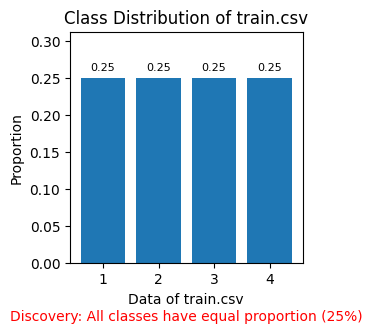

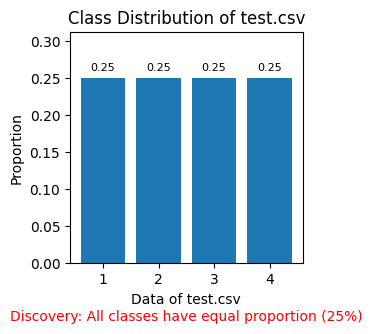

In [114]:
run_t1_analyze_class_distribution()

#### Analyze Average and median text length (overall and per class)

In [ ]:

def analyse_text_length(file_path):
    """ 
    Text Length is in the column "Description", what you need to do is to 
    1) calculate the length of description of each piece of data,
    2) sum up the length
    3) divide the summed up length with the length of the dataset
    4) calculate the median of the text length, median means
        if len is odd, then median is at the floor(len/2) + 1
        if len is even, then median is at len/2
    5) return the ave length and the median length as the return value

    Parameters:
        file_path: the path of the file which need to be calculated,e.g. train.csv
    Returns:
        ave_len: the average length of each piece of data
        median_len: the median length of each piece of data

    """

    df = pd.read_csv(file_path)
    descriptions = df["Description"].tolist()
    l = len(descriptions)
    description_len = np.array([len(x) for x in descriptions])
    sum_up_description_len = np.sum(description_len)
    median_index = int(np.floor(l/2))
    ave_len = round(sum_up_description_len / l,2)
    median_len = len(descriptions[median_index])
    # print(ave_len)
    # print(median_len)

    return ave_len,median_len


In [132]:
def run_analyse_text_length():
    paths = ["train.csv","test.csv"]
    for p in paths:
        ave, median = analyse_text_length(p)
        print("file name: ", p, "\n","average text length: ", ave, "\n","median text length: ", median)


print("Here is the discovery of text length analyse")
run_analyse_text_length()


Here is the discovery of text length analyse
file name:  train.csv 
 average text length:  193.39 
 median text length:  132
file name:  test.csv 
 average text length:  192.41 
 median text length:  154


#### Analyze Most frequent words per class

In [ ]:
def analyse_most_frequent_word(file_path):
    """ 
    You have to concatenate the Title and Description, then do analysis.
    how to know which word is most frequent in a class?
    1) collect data of same class into one collection
    2) in each collection of data, count its words frequency, then find the most frequent value
    3) visualize/summarize the result

    I don't know how to calculat them in a smart way
    how to know how many classes there are in the datasets?
    how to collect data by class?

    discovery:
        the most commom word is "the" in each class
    """

    df = pd.read_csv(file_path)
    df["text"] = df["Title"] + " " + df["Description"]
    class_collect = dict()

    ind_max = df.index.max()
    i = 0
    while i <= ind_max :
        dt_class = df["Class Index"][i]
        dt_text = df["text"][i]
        keys = class_collect.keys()
        if(dt_class in keys):
            class_collect[dt_class] = class_collect[dt_class] + " " + dt_text
        else:
            class_collect[dt_class] = dt_text
        i+=1

    frequency_collect = dict()
    for key, value in class_collect.items(): # tuple ("word", frequency)
        c = Counter(value.split()).most_common()[0]
        frequency_collect[key] = c

    for k,v in frequency_collect.items():
        print(k,v)
    


In [43]:
print("result of train.csv")
analyse_most_frequent_word("train.csv")
print("result of test.csv")
analyse_most_frequent_word("test.csv")
print(f"Discovery: the most commom word in the file train and test is \" the \" in each class")

result of train.csv
3 ('the', 37964)
4 ('the', 40705)
2 ('the', 56380)
1 ('the', 42476)
result of test.csv
3 ('the', 2497)
4 ('the', 2536)
2 ('the', 3563)
1 ('the', 2638)
Discovery: the most commom word in the file train and test is " the " in each class


#### Analyze Word clouds per class

In [2]:
def get_text_collection_by_class(file_path):
    df = pd.read_csv(file_path)
    df["text"] = df["Title"] + " " + df["Description"]
    class_collect = dict()

    ind_max = df.index.max()
    i = 0
    while i <= ind_max :
        dt_class = df["Class Index"][i]
        dt_text = df["text"][i]
        keys = class_collect.keys()
        if(dt_class in keys):
            class_collect[dt_class] = class_collect[dt_class] + " " + dt_text
        else:
            class_collect[dt_class] = dt_text
        i+=1
    return class_collect

In [3]:
train_dt_text_collect = get_text_collection_by_class("train.csv")
test_dt_text_collect = get_text_collection_by_class("test.csv")

word cloud of train dataset train
class:  3


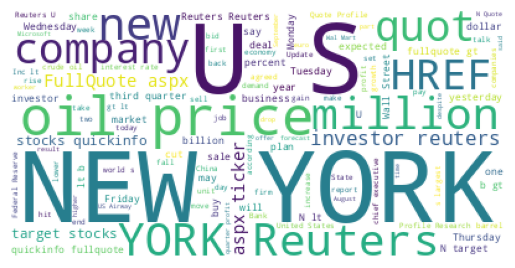

class:  4


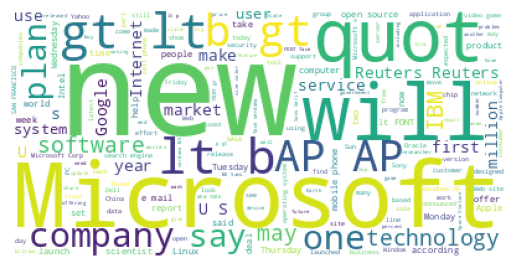

class:  2


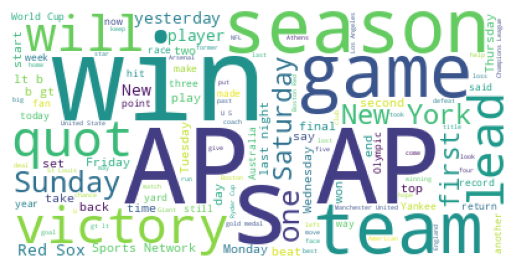

class:  1


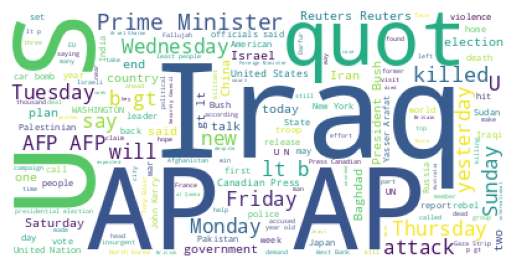



word cloud of test dataset test
class:  3


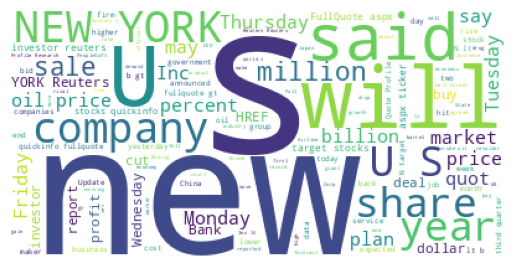

class:  4


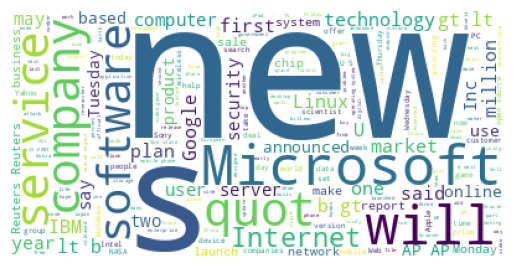

class:  2


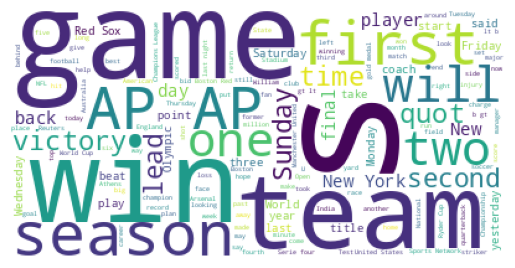

class:  1


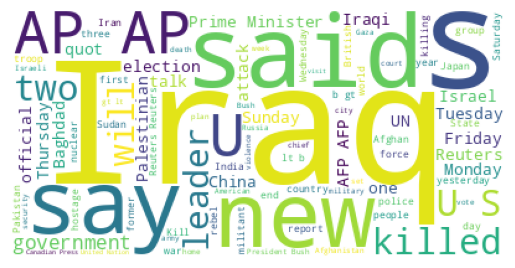

In [57]:
def draw_word_could(text_collect,title):
    print(f"word cloud of {title} dataset",title)
    for key, value in text_collect.items():
        wc = WordCloud(background_color="white").generate(value)
        print("class: ", key)
        plt.imshow(wc)
        plt.axis("off")
        plt.show()

draw_word_could(train_dt_text_collect,"train")
print("\n")
draw_word_could(test_dt_text_collect,"test")

#### Analyze Distribution of n-gram frequencies

In [74]:

""" 
1) generate n-grams
2) calculate n-grams' frequency
3) calculate its frequency's distribution

in the task above, we already have train_dt_text_collect, and test_dt_text_collect,
they have collected text(title+description) by class


what means distribution analyse
    - visualize distribution
    - categorize the distribution
    - statistische Merkmale

"""

def generate_ngram(n:int, token_list:list):
    """ 
    parameters:
        n: n gram's n
        tocken_list: a list of tocken. On this list we should apply ngram
    example:
        input: 
            n: 2
            tocken_list: ["Venezuelans", "Vote", "Early","in", "Referendum"]
        output: [('Venezuelans', 'Vote'), ('Vote', 'Early'), ('Early', 'in'), ('in', 'Referendum')]
    """

    return list(ngrams(token_list,n))
    

def ngram_frequency(n_grams_tocken_lst):
    r = Counter(n_grams_tocken_lst)
    return r

def topk_frequent_ngram(ngram_freq, k):
    return ngram_freq.most_common(k)

def visualize_ngram_distribution(ngram_freq,title):
    freqs = list(ngram_freq.values())
    freqs.sort(reverse=True)
    plt.figure(figsize=(7,2))
    plt.plot(freqs)
    title = "class: " + str(title)
    plt.title(title)
    plt.xlabel("Rank")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()
    

def run_ngram_distribution_analyse(dt_text_collect,n):
    for key, value in dt_text_collect.items():
        ngrams = generate_ngram(n,list(value.split()))
        freqs = ngram_frequency(ngrams)
        visualize_ngram_distribution(freqs,key)
    


Discovery: the ngram frequency follows Long-tail distribution


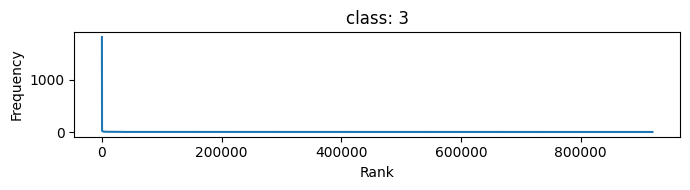

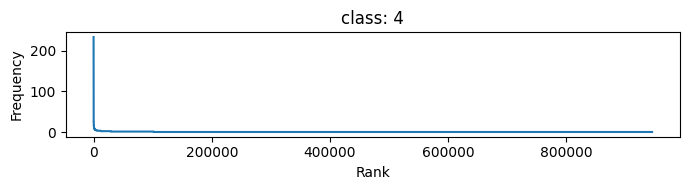

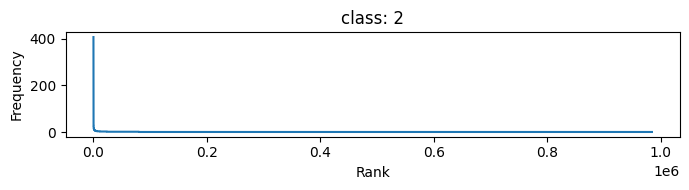

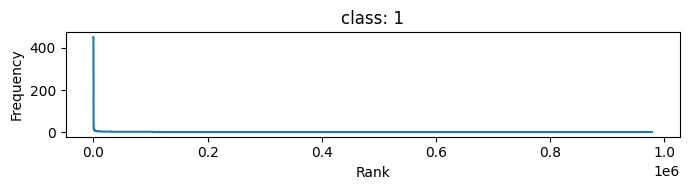

In [77]:
print("Discovery: the ngram frequency follows Long-tail distribution")
run_ngram_distribution_analyse(train_dt_text_collect,4)

#### Analyze ...

### Task 2: Pre-processing (15%)

#### Task Description
Design and implement a preprocessing pipeline suitable for text modeling.

Possible components include:

- Tokenization  
- Lowercasing  
- Stopword removal  
- Stemming or lemmatization  
- Handling punctuation or numbers  
- Subword tokenization (for Transformer models)

---

#### Report Requirements

In your report, you should:

- Clearly describe your final preprocessing pipeline  
- Justify which steps you included and which you excluded

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from wordcloud import WordCloud
from nltk.util import ngrams
import nltk
from nltk.tokenize import word_tokenize,RegexpTokenizer
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer,WordNetLemmatizer
import re
from transformers import AutoTokenizer
import torch
from tqdm.auto import tqdm
from sklearn.feature_extraction.text import TfidfVectorizer
print("torch version:", torch.__version__)

torch version: 2.9.1


In [49]:
"""
After donwload "punkt", and "punkt_tab", you can use word_tokenize 
directly, without "preserve_line=True"

If you not download it, you have to use word_tokenize in this way:
a = "I love NLP, how about You?"
b = word_tokenize(a,preserve_line=True)
"""
nltk.download("punkt")
nltk.download("punkt_tab")  # optional, depends on NLTK version

nltk.download("stopwords")
nltk.download('wordnet')    
nltk.download('omw-1.4') 
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt to /Users/baturu/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/baturu/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/baturu/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/baturu/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /Users/baturu/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/baturu/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [ ]:
# very useful links
# https://www.geeksforgeeks.org/nlp/natural-language-processing-nlp-tutorial/
# https://huggingface.co/docs/transformers/tokenizer_summary

class Preprocessor():

    def __init__(self,file_path: str, transformer_name: str = "bert-base-uncased"):

        """
        the file itself has format
        Class Index, Title, Description
        number        str      str

        parameter:
            file_path: the path of the file, the file is supposed to be a csv file
        """
        self.file_path = file_path
        self.dt_raw = pd.read_csv(file_path)
        self.transformer_name = transformer_name
        self.hf_tokenizer = AutoTokenizer.from_pretrained(transformer_name, use_fast=True) # hf stands for hugging face

    def tockenize(self,text:str) -> list:
        """
        Question:
            nltk.tokenize has many kinds of tokenizer, should we pass tokenizer as parameter?
        """
        return word_tokenize(text)
        
    def lowercase(self,text:str) -> str:
        return text.lower()
    

    def rm_stopword(self, tokens:list[str]):
        """
        This function removes stopwords, suppose the text's language is english.

        what is stop words? 
            Stop words typically fall into these grammatical categories:
            Articles: a, an, the
            Prepositions: in, on, at, of, for, with, about
            Conjunctions: and, but, or, so, because
            Pronouns: I, you, he, she, it, we, they, this, that, these
            Auxiliary Verbs: is, am, are, was, were, be, been, have, has, had, do, does, did
            Common Verbs/Adverbs: can, will, would, should, very, too, just, not (see caution below)
        """
        stop_words = set(stopwords.words("english"))
        filtered_tokens = [
            word for word in tokens
            if word.lower() not in stop_words
            and word.isalpha()   # remove punctuation
        ]
        return filtered_tokens
    
    def stemming(self, tokens:list[str]):
        """
        This function reduces words to their root form, often result in non-valid words.

        Question: 
            what is difference, pros, cons between different stemmers?

        example:
            Original words: ['running', 'jumps', 'happily', 'running', 'happily']
            Stemmed words: ['run', 'jump', 'happili', 'run', 'happili']
        """
        stemmer = PorterStemmer()
        stemmed_tokens = [stemmer.stem(word) for word in tokens]
        return stemmed_tokens
        
    # lemmatization it
    def lemmatize(self,tokens:list[str])  ->list:
        """
        This function reduces words to their base form(lemma), ensuring a valid word.

        example:
            Original Text: The cats were running faster than the dogs.
            Lemmatized Words: ['The', 'cat', 'were', 'running', 'faster', 'than', 'the', 'dog', '.']
        """
        lemmatizer = WordNetLemmatizer()
        lemmatized_words = [lemmatizer.lemmatize(word) for word in tokens]
        return lemmatized_words
    
    
    def handle_punctuation_and_num(self,text:str)-> list:
        """
        This function handles(removes) punctuation and numbers of the input text.

        Regex:
            \w+           it keeps words + numbers
            [A-Za-z]+     it only keeps letters

        parameters:
            text: a string, we'll handle punctuation and number on this text
        return:
            a list of words, which has excluded punctuation and numbers
        example:
            input text:     "# + , punctuation and numbers like 123."
            output result:  ['punctuation', 'and', 'numbers', 'like']
        """
        tokenizer = RegexpTokenizer(r'[A-Za-z]+')
        tokenized_text_lst = tokenizer.tokenize(text)
        return tokenized_text_lst


    def tokenize_subword_transformer(self,text:str, add_special_tokens: bool = True) -> dict:
        """
        Returns subword tokens and token ids for a Transformer tokenizer.

        add_special_tokens:
          - True: includes [CLS]/[SEP] for BERT-like models
          - False: raw subword pieces only
        """
        ids = self.hf_tokenizer.encode(text, add_special_tokens=add_special_tokens)
        tokens = self.hf_tokenizer.convert_ids_to_tokens(ids)
        return {"tokens": tokens, "ids": ids}
    
    def classic_pipeline(
        self,
        use_title: bool = True,
        use_description: bool = True,
        join_with: str = " [SEP] ",     # 仅作为分隔符，classic里也OK
        use_regexp_tokenizer: bool = True,
        remove_stopwords: bool = True,
        do_stemming: bool = False,
        do_lemmatize: bool = True,
        make_tfidf: bool = True,
        tfidf_ngram_range: tuple = (1, 2),
        tfidf_min_df: int = 2,
        tfidf_max_df: float = 0.95,
    ):
        """
        Classical NLP pipeline:
        - Merge Title + Description into one text per row
        - Lowercase
        - Tokenize (RegexpTokenizer OR NLTK word_tokenize)
        - (optional) remove stopwords + punctuation + numbers
        - (optional) lemmatize OR stem
        - Create clean_text = " ".join(tokens)
        - (optional) TF-IDF vectorization

        Returns:
          df_out, (X_tfidf, vectorizer) if make_tfidf else df_out
        """
        df = self.dt_raw.copy()

        # ---- 1) basic cleaning + merge text per row ----
        for col in ["Title", "Description"]:
            if col in df.columns:
                df[col] = df[col].fillna("").astype(str)

        parts = []
        if use_title and "Title" in df.columns:
            parts.append(df["Title"])
        if use_description and "Description" in df.columns:
            parts.append(df["Description"])

        if not parts:
            raise ValueError("No text columns selected. Check use_title/use_description and CSV headers.")

        if len(parts) == 1:
            df["text"] = parts[0].astype(str).str.strip()
        else:
            df["text"] = parts[0].astype(str).str.strip() + join_with + parts[1].astype(str).str.strip()

        # labels
        if "Class Index" not in df.columns:
            raise ValueError("Column 'Class Index' not found in CSV.")
        df["y"] = df["Class Index"].astype(int)

        # ---- 2) lowercase ----
        df["text"] = df["text"].apply(self.lowercase)

        # ---- 3) tokenize ----
        if use_regexp_tokenizer:
            # regex already removes punctuation/numbers
            df["tokens"] = df["text"].apply(self.handle_punctuation_and_num)
        else:
            # NLTK tokenization keeps punctuation; we'll filter later
            df["tokens"] = df["text"].apply(self.tockenize)

        # ---- 4) optional: remove stopwords + keep alpha ----
        if remove_stopwords:
            df["tokens"] = df["tokens"].apply(self.rm_stopword)
        else:
            # even if not removing stopwords, still remove non-alpha if you used NLTK tokenizer
            if not use_regexp_tokenizer:
                df["tokens"] = df["tokens"].apply(lambda toks: [t for t in toks if t.isalpha()])

        # ---- 5) optional: lemmatize / stem (choose one) ----
        if do_stemming and do_lemmatize:
            raise ValueError("Choose either stemming OR lemmatize, not both.")
        if do_lemmatize:
            df["tokens"] = df["tokens"].apply(self.lemmatize)
        elif do_stemming:
            df["tokens"] = df["tokens"].apply(self.stemming)

        # ---- 6) build clean_text for vectorizer ----
        df["clean_text"] = df["tokens"].apply(lambda toks: " ".join(toks))

        # ---- 7) TF-IDF vectorization (optional) ----
        if not make_tfidf:
            return df[["y", "text", "tokens", "clean_text"]]

        vectorizer = TfidfVectorizer(
            ngram_range=tfidf_ngram_range,
            min_df=tfidf_min_df,
            max_df=tfidf_max_df,
            sublinear_tf=True,
            max_features=20000,
        )
        X_tfidf = vectorizer.fit_transform(df["clean_text"])

        return df[["y", "text", "tokens", "clean_text"]], X_tfidf, vectorizer
    
        

<>:88: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
<>:88: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
/var/folders/kw/qrl_mkc50r98y8l95mp8w2g00000gn/T/ipykernel_6149/1834162717.py:88: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
  \w+           it keeps words + numbers


In [7]:
p = Preprocessor("train.csv")

df_out, X, vec = p.classic_pipeline(
    use_regexp_tokenizer=True,     
    remove_stopwords=True,
    do_lemmatize=True,
    do_stemming=False,
    make_tfidf=True,
    tfidf_ngram_range=(1,2)
)

print(df_out.head())
print(X.shape)
print(vec.get_feature_names_out()[:20])


   y                                               text  \
0  3  wall st. bears claw back into the black (reute...   
1  3  carlyle looks toward commercial aerospace (reu...   
2  3  oil and economy cloud stocks' outlook (reuters...   
3  3  iraq halts oil exports from main southern pipe...   
4  3  oil prices soar to all-time record, posing new...   

                                              tokens  \
0  [wall, st, bear, claw, back, black, reuters, s...   
1  [carlyle, look, toward, commercial, aerospace,...   
2  [oil, economy, cloud, stock, outlook, reuters,...   
3  [iraq, halt, oil, export, main, southern, pipe...   
4  [oil, price, soar, time, record, posing, new, ...   

                                          clean_text  
0  wall st bear claw back black reuters sep reute...  
1  carlyle look toward commercial aerospace reute...  
2  oil economy cloud stock outlook reuters sep re...  
3  iraq halt oil export main southern pipeline re...  
4  oil price soar time record pos

In [8]:
df_out, X, vec = p.classic_pipeline()
y = df_out["y"].values

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

clf = LogisticRegression(max_iter=2000)
clf.fit(X_train, y_train)
print("acc:", clf.score(X_test, y_test))


acc: 0.9213333333333333


### Task 3: Classical Language Modeling (20%)

#### Task 3.1 – N-gram Language Models
For this task you should implement a bigram and a trigram language model
Requirements:

- Compute smoothed probabilities (e.g., Laplace smoothing)
- Generate short text sequences from each model
- Compute and compare perplexity across n-gram sizes

#### Task 3.2 – Comparison with a Neural Language Model
Build a simple neural language model consisting of:

- An embedding layer
- One LSTM or GRU layer
- A softmax output layer

Then compare against n-gram models on:

- Perplexity
- Quality of generated text
- And, Training time

### Task 4: Transformer Fine-tuning (30%)

Fine-tune a lightweight transformer model on the dataset.
Suggested model:

- DistilBERT

Requirements:

- Split the data into train/validation/test split
- Implement at least two tokenization approaches (e.g., WordPiece vs. Byte-Pair Encoding)
- Evaluation metrics:

- Accuracy
- Macro-F1
- Confusion matrix

In [ ]:
# https://www.acm.org/publications/proceedings-template

### Task 5: Model Evaluation & Benchmarking (20%)
Evaluate your models using multiple perspectives. First, randomly subsample 100 test instances and
evaluate your model on them, and test different evaluation approaches:

- Metric-based evaluation (accuracy, F1, perplexity) - like a standard evaluation as above, using
the gold labels
- Human evaluation (you & teammates give ratings) - this would represent a scenario in which
you would not have any gold label, and you need to create the ground truth by yourself
- LLM-as-a-judge evaluation (use any local small LLM or API-free model like Llama 3.1 8B local)
    - this would represent a scenario in which, again, no gold labels would be available, but
instead of annotating them manually, you use an LLM to judge the results.

Analyze differences between gold labels across the three different evaluations.

### Task 6 Report Requirements (3–4 pages)
Your report must include:

- Clear explanation of pipeline design
- Key findings in each task
- All evaluation results and metrics
- Hyperparameters for all models
- Challenges and limitations